In [1]:
import matplotlib.pyplot as plt
from csv import reader
from math import sqrt
from random import sample

selection: list = []
selection_len: int = 0

with open('var_8_loglaplace.csv', mode ='r')as file:
    csvFile = reader(file)
    for lines in csvFile:
        selection.append(float(lines[0]))
        selection_len += 1

Сумма элементов выборки:

In [2]:
def my_sum(array: list) -> float:
    summa: int = 0
    for elem in selection:
        summa += elem
    return summa

In [3]:
my_sum(selection)

-667.933908

Выборочное среднее:

In [4]:
def mid(selection: list) -> float:
    summa: int = my_sum(selection)
    return summa / selection_len

Значение выборочного среднего для конкретной выборки:

In [5]:
mid(selection)

-2.2264463599999997

In [6]:
def median(selection: list) -> float:
    sorted_selection: list = sorted(selection)
    if selection_len % 2 == 0:
        half: int = int(selection_len / 2)
        return (selection[half] + selection[half + 1]) / 2
    else:
        return selection[half]

In [7]:
median(selection)

-1.5544155

Мода:

In [8]:
def moda(selection: list) -> float:
    freq_dict = {}
    for elem in selection:
        freq_dict[elem] = freq_dict.get(elem, 0) + 1
        
    max_freq: int = max(freq_dict.values())

    if(max_freq == 1):
        return None
    
    for key, value in freq_dict.items():
        if value == max_freq:
            return key

In [9]:
print(moda(selection))

None


Размах выборки:

In [10]:
def razmah(selection: list) -> float:
    return max(selection) - min(selection)

In [11]:
razmah(selection)

2.2436290000000003

Смещенная дисперсия:

In [12]:
def smesh_dispersion(selection: list) -> float:
    mid_val: float = mid(selection)
    summa: float = 0
    for elem in selection:
        summa += (mid_val - elem) ** 2
    return sqrt(summa / selection_len)

In [13]:
smesh_dispersion(selection)

0.33716743926025394

Несмещенная дисперсия:

In [14]:
def nesmesh_dispersion(selection: list) -> float:
    mid_val: float = mid(selection)
    summa: float = 0
    for elem in selection:
        summa += (mid_val - elem) ** 2
    return sqrt(summa / (selection_len - 1))

In [15]:
nesmesh_dispersion(selection)

0.3377307937705018

Выборочный начальный элемент:

In [16]:
def choose_first_elem(selection: list, k: int) -> float:
    summa: float = 0
    for elem in selection:
        summa += elem ** k
    return summa / selection_len

In [17]:
choose_first_elem(selection, 3)

-11.748076371347292

Выборочный центральный элемент:

In [18]:
def choose_center_elem(selection: list, k: int) -> float:
    mid_val: float = mid(selection)
    summa: float = 0
    for elem in selection:
        summa += (mid_val - elem) ** k
    return sqrt(summa / selection_len)

In [19]:
choose_center_elem(selection, 6)

0.30550255295838474

Эмперическая функция распределения:

In [20]:
def ecdf(selection: list, count: int):
    sorted_selection = sorted(selection)

    x = []
    y = []

    for i in range(count):
        x.append(sorted_selection[i])
        y.append((i + 1) / count)

    return x, y

График эмперической функции:

In [21]:
def show_graphic_ecdf(x: list, y: list):
    plt.figure()
    plt.step(x, y, where='post', label="Эмперическая функция")
    plt.scatter(x, y, label="Точки выборки")
    
    plt.xlabel('x')
    plt.ylabel('F(x)')
    plt.title('Эмперическая функция распределения')
    plt.legend()
    plt.grid()
    
    plt.show()

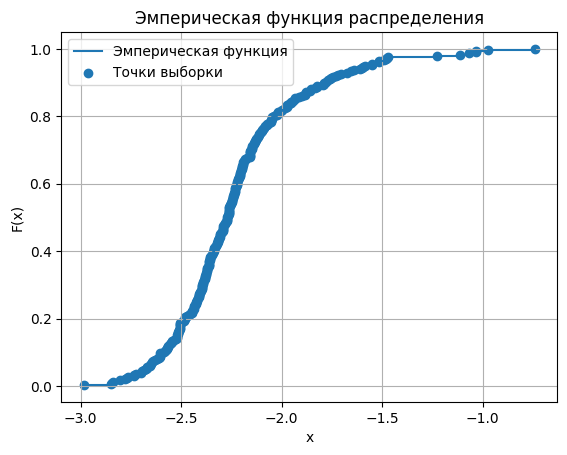

In [22]:
x, y = ecdf(selection, selection_len)
show_graphic_ecdf(x, y)

График эмперичиской функции для 10 случайных элементов:

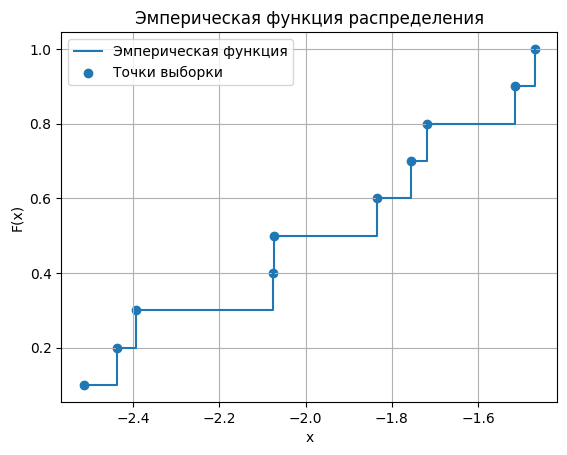

In [23]:
selection_10 = sample(selection, 10)
x, y = ecdf(selection_10, 10)
show_graphic_ecdf(x, y)

График эмперичиской функции для 100 случайных элементов:

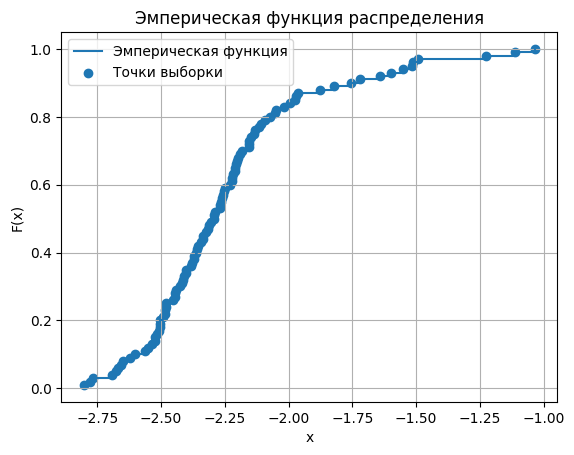

In [24]:
selection_100 = sample(selection, 100)
x, y = ecdf(selection_100, 100)
show_graphic_ecdf(x, y)

График эмперичиской функции для 200 случайных элементов:

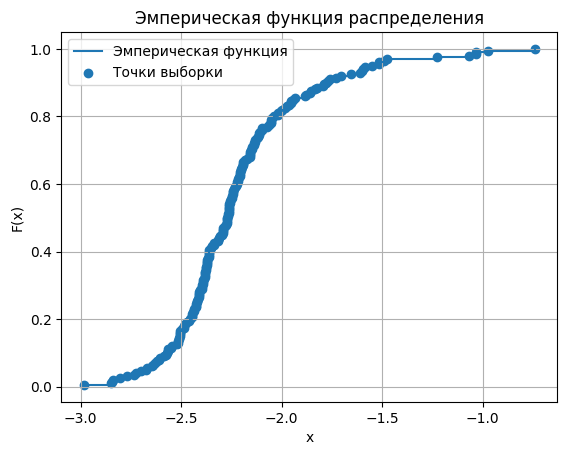

In [25]:
selection_200 = sample(selection, 200)
x, y = ecdf(selection_200, 200)
show_graphic_ecdf(x, y)

In [26]:
def histogram(selection: list, bins=10):
    min_val = min(selection)
    max_val = max(selection)

    bin_width: float = (max_val - min_val) / bins

    edges = [min_val + i * bin_width for i in range(bins + 1)]

    counts = [0] * bins

    for elem in selection:
        for i in range(bins):
            if(edges[i] <= elem < edges[i+1]):
                counts[i] += 1
                break
        else:
            counts[-1] += 1

    return edges, counts

Гистограмма:

In [27]:
def show_histogram(edges: list, counts: list):
    centers = [(edges[i] + edges[i+1]) / 2 for i in range(len(edges)-1)]
    
    plt.figure()
    
    plt.bar(centers, counts, width=(edges[1] - edges[0]), alpha=0.6, label="Гистограмма")
    
    plt.plot(centers, counts, marker='o', label="График частот")
    
    plt.title("Гистограмма")
    plt.xlabel("Значения")
    plt.ylabel("Частота")
    plt.legend()
    plt.grid()
    
    plt.show()

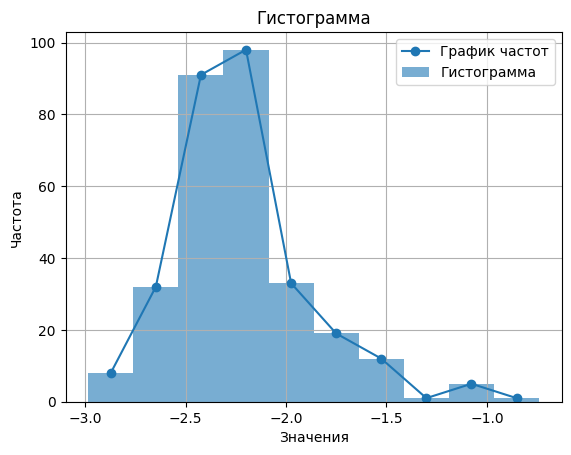

In [28]:
edges, counts = histogram(selection)
show_histogram(edges, counts)

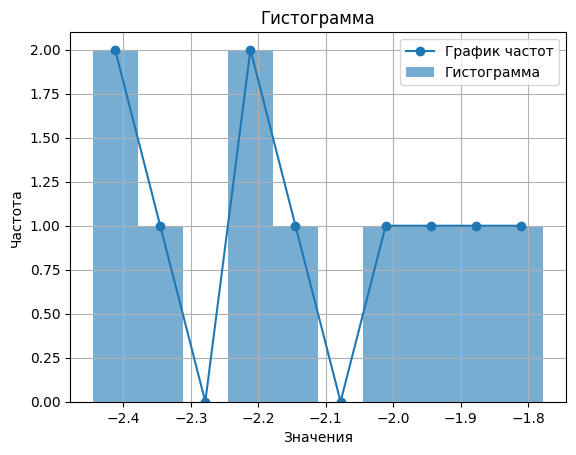

In [29]:
selection_10 = sample(selection, 10)
edges, counts = histogram(selection_10, 10)
show_histogram(edges, counts)

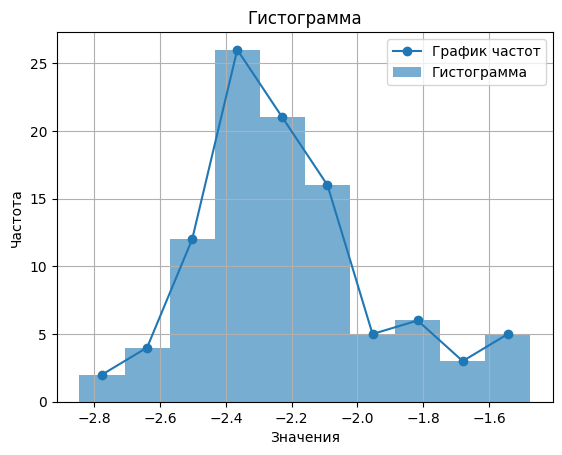

In [30]:
selection_100 = sample(selection, 100)
edges, counts = histogram(selection_100)
show_histogram(edges, counts)

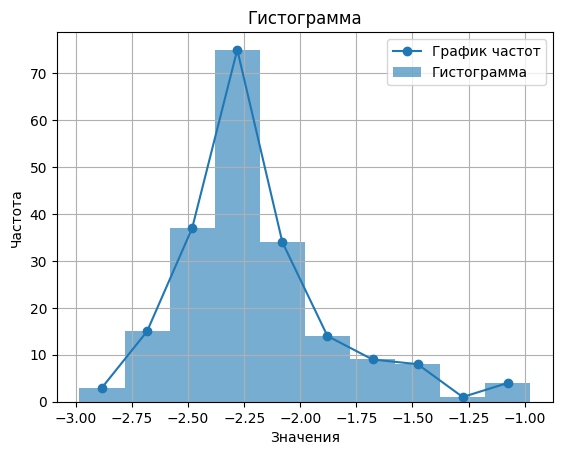

In [31]:
selection_200 = sample(selection, 200)
edges, counts = histogram(selection_200)
show_histogram(edges, counts)